# 🤖 Project Budget & Duration Predictor
Predicts **final_budget_usd** and **duration_days** from project features.

Prices are normalized to **USD** (via the daily `usd_rate`) instead of raw IRR,
since IRR has been too unstable over this dataset's ~15-year span to be a
meaningful regression target on its own.

Sections:
1. Load & inspect
2. Target engineering (USD normalization, null handling, log transform)
3. Feature engineering & encoding
4. EDA — distributions, correlations
5. Train models — classical ML (GradientBoosting, Random Forest, XGBoost)
6. Train a deep learning model (feed-forward neural net)
7. Classical vs Deep Learning comparison
8. Feature importance (classical models)
9. SHAP — per-prediction explanations
10. Error analysis
11. Cross-validation
12. Inference helper

In [4]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
ACCENT, ACCENT2 = '#5B8DEF', '#F4845F'

# ── Paths ────────────────────────────────────────────────────────────────
CSV_PATH = Path('../ml_dataset/full_dataset.csv')   # <-- adjust if needed
# CSV_PATH = Path('/absolute/path/to/full_dataset.csv')

BUDGET_RATIO_THRESHOLD = 3.0  # max/min ratio to accept imputed budget (avg of min/max)

# Only rows with a resolvable USD exchange rate can have a USD target.
# (build_dataset.py already computes this from the nearest available
# daily rate, average of open/high/low/close, keyed off scraped_date_created.)
REQUIRE_USD_RATE = True

ENUM_COLS = [
    'project_type', 'ai_level', 'business_logic', 'data_volume',
    'integration_complexity', 'ui_complexity', 'algorithmic_complexity'
]
# Columns that are not model inputs
NON_FEATURE = [
    'project_id','title','category','organization','created_at','scraped_date_created',
    'final_budget','log_final_budget','budget_min','budget_max','log_budget_min','log_budget_max',
    'budget_range','budget_range_ratio','has_final_budget','duration','duration_days',
    'description','skills','outer_link','updated_at','category_scraped_id','description_length', 'description_word_count', 'skill_count',
    # USD normalization columns (rate + amounts) — inputs to target engineering,
    # not model features themselves
    'usd_rate','usd_rate_date','final_budget_usd','log_final_budget_usd',
    'budget_min_usd','budget_max_usd','log_budget_min_usd','log_budget_max_usd',
    'budget_range_usd',
    # derived targets added later
    'target_budget','is_budget_imputed','target_duration','is_days_null',
    'log_target_budget','log_target_duration',
]

df_raw = pd.read_csv(CSV_PATH)
print(f'✅  {len(df_raw):,} rows  ·  {df_raw.shape[1]} columns')
print(f'    Organizations: {df_raw.organization.unique()}')

if REQUIRE_USD_RATE and 'usd_rate' in df_raw.columns:
    n_no_rate = df_raw['usd_rate'].isna().sum()
    print(f'    Rows with no usable USD rate (dropped before modeling): '
          f'{n_no_rate:,} ({n_no_rate/len(df_raw):.1%})')

df_raw.head(2)

✅  5,622 rows  ·  164 columns
    Organizations: <StringArray>
['Karlancer', 'Ponisha']
Length: 2, dtype: str
    Rows with no usable USD rate (dropped before modeling): 0 (0.0%)


,project_id,title,category,organization,created_at,scraped_date_created,usd_rate,usd_rate_date,final_budget,log_final_budget,...,data_volume,integration_complexity,ui_complexity,algorithmic_complexity,updated_at,category_scraped_id,feature_score_sum,feature_count,feature_score_mean,feature_score_max
0,a6ae2518-7cb9-4915-8629-13090f989342,ساخت بات فروشگاهی تلگرام,پروژه‌های برنامه نویسی,Karlancer,2026-06-25T08:48:44.751434,2026-06-11 05:03:00,1795650.0,2026-06-11,500000.0,13.122365,...,small,low,low,low,2026-06-25 08:48:44.751434,6,11,3,0.134146,4
1,2e8ba95c-7051-4099-9e4f-02c85b549ae5,ساخت ربات تلگرام,پروژه‌های برنامه نویسی,Karlancer,2026-06-25T08:48:46.121224,2026-06-02 09:39:53,1746287.5,2026-06-02,1500000.0,14.220976,...,small,low,low,low,2026-06-25 08:48:46.121224,6,10,3,0.121951,4


## 1 · Target engineering
**USD normalization:** every budget figure is converted from IRR to USD using
`usd_rate` (nearest available daily rate) *before* any null-handling. Rows with
no resolvable `usd_rate` are dropped — we can't meaningfully price a project
without knowing what its IRR figure was worth at the time.

**Budget null rule:** if `final_budget_usd` is null and `budget_max_usd / budget_min_usd ≤ threshold` → use average of min/max. Otherwise drop the row.

**Duration null rule:** fill with dataset median, add `is_days_null` flag so the model knows the value was imputed.

Rows dropped (no USD rate): 0
Rows before: 5,622  |  dropped (ratio too high): 800  |  kept: 4,822
Budget imputed (avg min/max): 878
Duration filled with median (5 days): 0



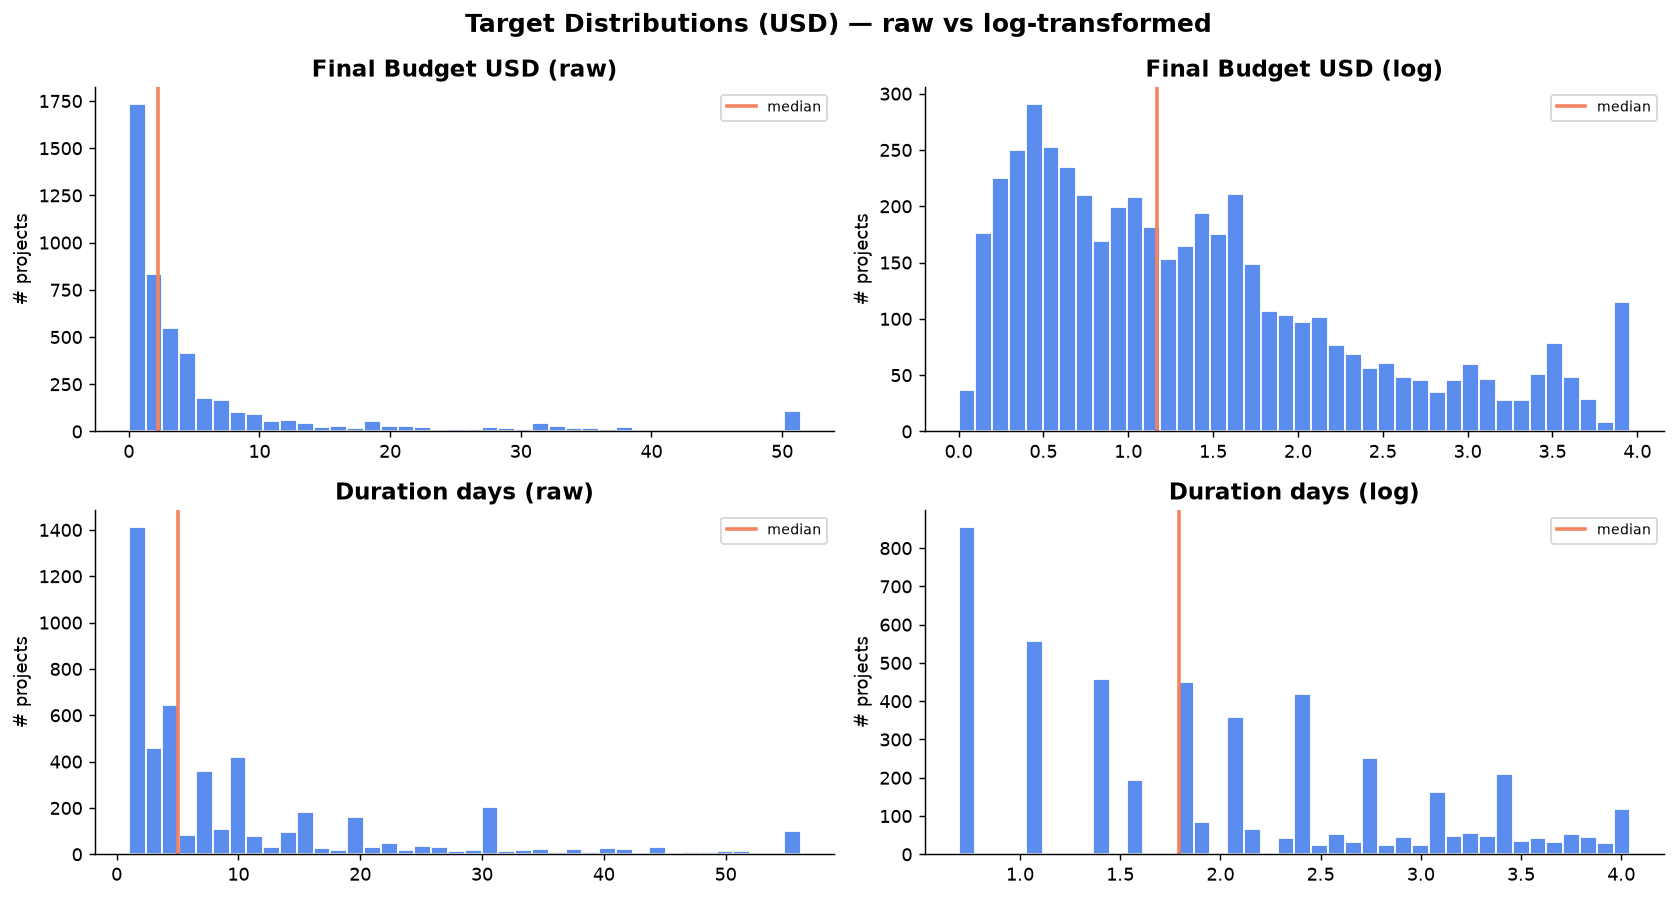

In [5]:
# Drop rows with no usable USD rate first — everything downstream is USD-denominated.
df = df_raw[df_raw['usd_rate'].notna()].copy() if REQUIRE_USD_RATE else df_raw.copy()
n_dropped_no_rate = len(df_raw) - len(df)

# ── Budget (USD) ─────────────────────────────────────────────────────────
def resolve_final_budget(row):
    if pd.notna(row['final_budget_usd']):
        return row['final_budget_usd'], False   # (value, is_imputed)
    ratio = row['budget_max_usd'] / max(row['budget_min_usd'], 1e-6)
    if ratio <= BUDGET_RATIO_THRESHOLD:
        return (row['budget_min_usd'] + row['budget_max_usd']) / 2, True
    return np.nan, False   # ratio too high → will be dropped

df[['target_budget', 'is_budget_imputed']] = df.apply(
    lambda r: pd.Series(resolve_final_budget(r)), axis=1
)
before = len(df)
df = df[df['target_budget'].notna()].copy()
dropped = before - len(df)

# ── Duration ─────────────────────────────────────────────────────────────
duration_median = df['duration_days'].median()
df['is_days_null'] = df['duration_days'].isna().astype(int)
df['target_duration'] = df['duration_days'].fillna(duration_median)

# ── Log-transform targets (right-skewed money/time values) ────────────────
df['log_target_budget']   = np.log1p(df['target_budget'])
df['log_target_duration'] = np.log1p(df['target_duration'])

print(f'Rows dropped (no USD rate): {n_dropped_no_rate:,}')
print(f'Rows before: {before:,}  |  dropped (ratio too high): {dropped}  |  kept: {len(df):,}')
print(f'Budget imputed (avg min/max): {df.is_budget_imputed.sum()}')
print(f'Duration filled with median ({duration_median:.0f} days): {df.is_days_null.sum()}')
print()

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, col, label in [
    (axes[0,0], 'target_budget',       'Final Budget USD (raw)'),
    (axes[0,1], 'log_target_budget',   'Final Budget USD (log)'),
    (axes[1,0], 'target_duration',     'Duration days (raw)'),
    (axes[1,1], 'log_target_duration', 'Duration days (log)'),
]:
    ax.hist(df[col].clip(upper=df[col].quantile(0.98)), bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(df[col].median(), color=ACCENT2, linewidth=2, label='median')
    ax.set_title(label); ax.set_ylabel('# projects'); ax.legend(fontsize=8)
fig.suptitle('Target Distributions (USD) — raw vs log-transformed', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 2 · Feature engineering & encoding

In [6]:
# Ordinal encode enums (low=0, medium=1, high=2 etc.)
ENUM_ORDER = {
    'project_type':           ['new','maintenance','migration','bugfix','optimization','testing','consulting'],
    'ai_level':               ['none','basic','advanced'],
    'business_logic':         ['low','medium','high'],
    'data_volume':            ['small','medium','large'],
    'integration_complexity': ['low','medium','high'],
    'ui_complexity':          ['low','medium','high'],
    'algorithmic_complexity': ['low','medium','high'],
}
enc = OrdinalEncoder(categories=[ENUM_ORDER[c] for c in ENUM_COLS], handle_unknown='use_encoded_value', unknown_value=-1)
df[ENUM_COLS] = enc.fit_transform(df[ENUM_COLS].astype(str))

# Final feature list: everything not in NON_FEATURE and not object dtype
ALL_FEATURES = [
    c for c in df.columns
    if c not in NON_FEATURE and df[c].dtype != object
]
print(f'Model input features: {len(ALL_FEATURES)}')
print('Sample:', ALL_FEATURES[:10], '...')

X  = df[ALL_FEATURES]
yB = df['log_target_budget']
yD = df['log_target_duration']

X_tr, X_te, yB_tr, yB_te, yD_tr, yD_te = train_test_split(
    X, yB, yD, test_size=0.2, random_state=42
)
print(f'Train: {len(X_tr):,}  |  Test: {len(X_te):,}')

Model input features: 131
Sample: ['Authentication', 'Authorization & Role Management', 'User Management', 'User Profiles', 'Infrastructure & Operations', 'Administration Panel', 'Dashboard', 'Settings & Configuration', 'Content Management', 'Rich Text Editing'] ...
Train: 3,857  |  Test: 965


## 3 · EDA — target vs key features

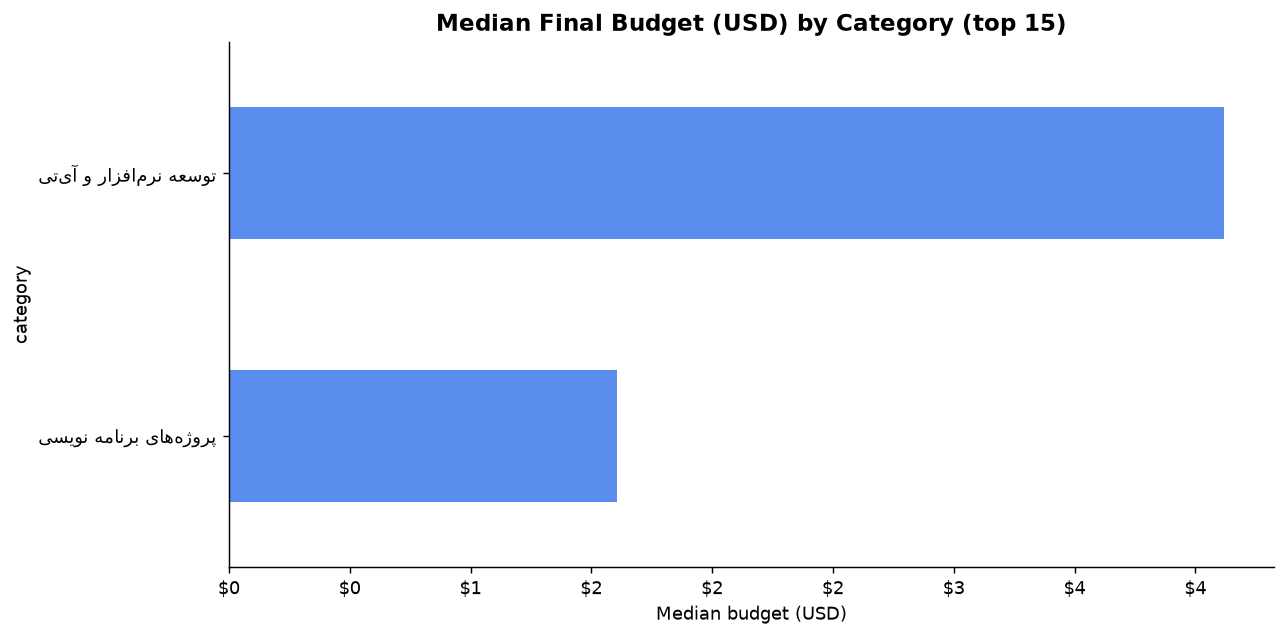

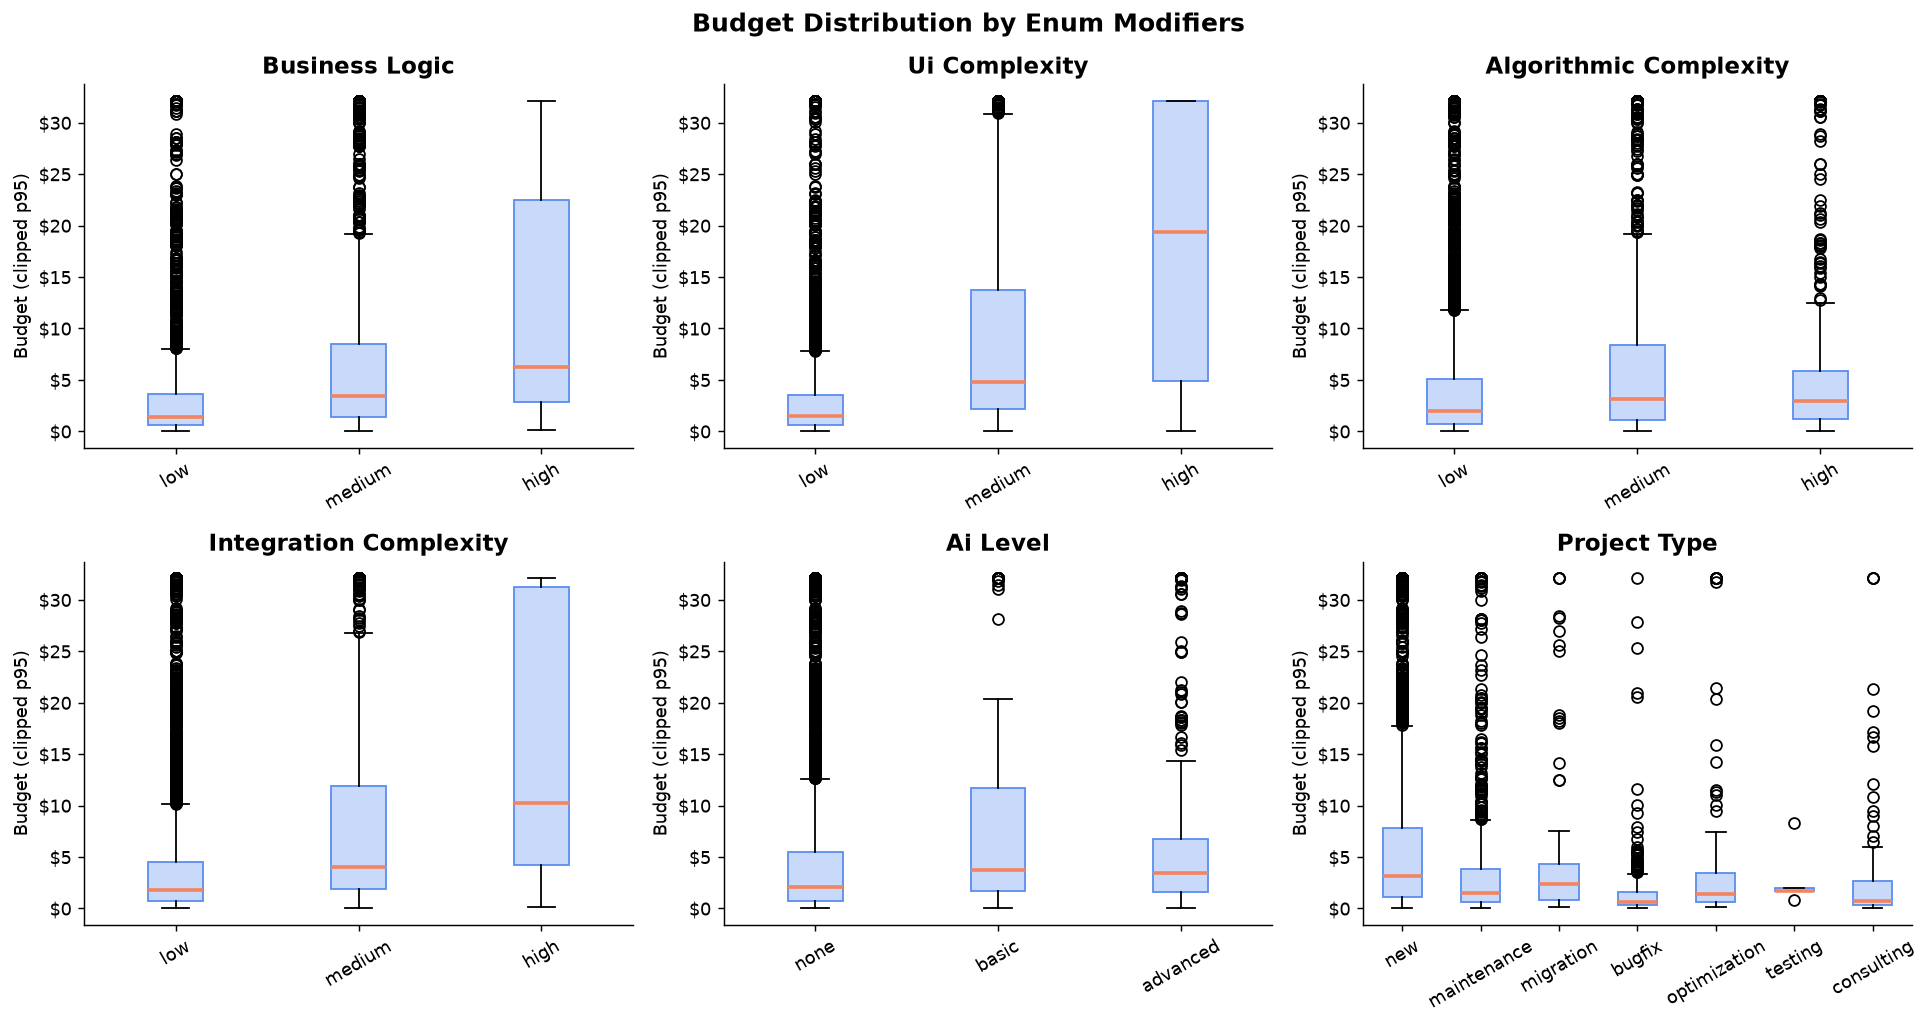

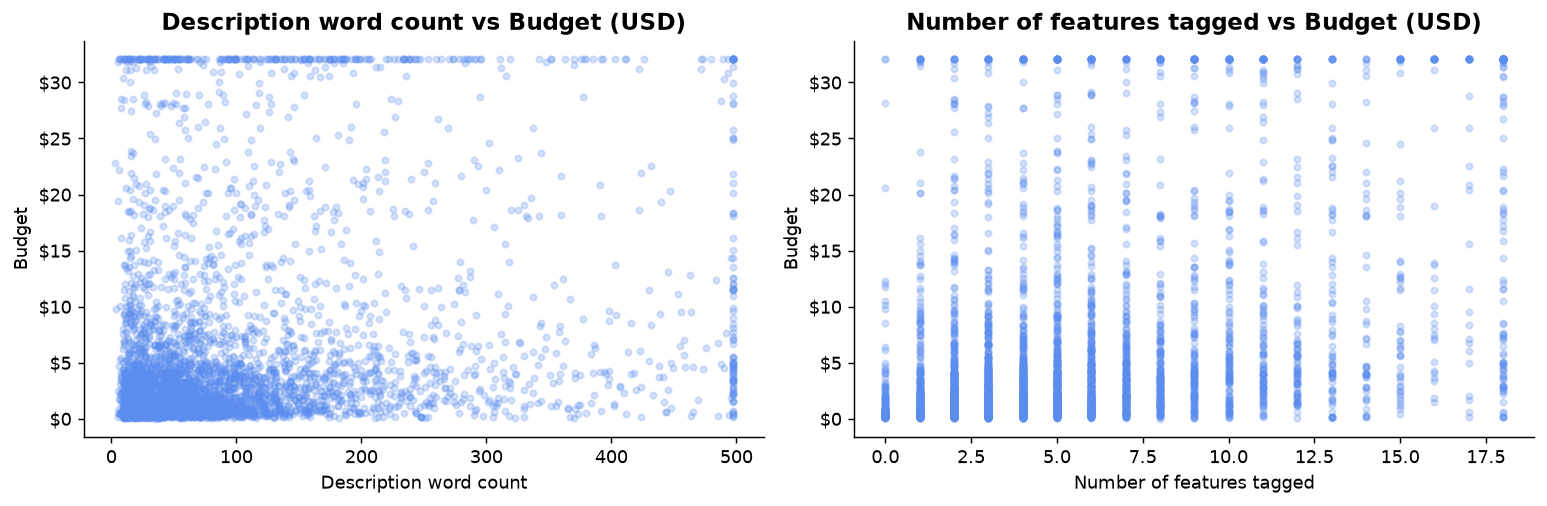

In [7]:
# Budget by category (top 15 by median)
cat_budget = (df.groupby('category')['target_budget']
                .median().sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(10, 5))
cat_budget.plot(kind='barh', ax=ax, color=ACCENT)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Median Final Budget (USD) by Category (top 15)')
ax.set_xlabel('Median budget (USD)')
plt.tight_layout(); plt.show()

# Budget vs complexity enums
raw_enum_cols = ['business_logic','ui_complexity','algorithmic_complexity','integration_complexity','ai_level','project_type']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), raw_enum_cols):
    order = ENUM_ORDER.get(col, sorted(df_raw[col].dropna().unique()))
    present = [v for v in order if v in df_raw[col].values]
    data = [df.loc[df_raw.loc[df.index, col] == v, 'target_budget'].clip(upper=df['target_budget'].quantile(0.95))
            for v in present]
    ax.boxplot(data, tick_labels=present, patch_artist=True,
               boxprops=dict(facecolor=ACCENT+'55', color=ACCENT),
               medianprops=dict(color=ACCENT2, linewidth=2))
    ax.set_title(col.replace('_',' ').title())
    ax.set_ylabel('Budget (clipped p95)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Budget Distribution by Enum Modifiers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Scatter: description length vs budget
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, xcol, xlabel in [
    (axes[0], 'description_word_count', 'Description word count'),
    (axes[1], 'feature_count', 'Number of features tagged'),
]:
    ax.scatter(df[xcol].clip(upper=df[xcol].quantile(0.98)),
               df['target_budget'].clip(upper=df['target_budget'].quantile(0.95)),
               alpha=0.25, s=12, color=ACCENT)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Budget')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(f'{xlabel} vs Budget (USD)')
plt.tight_layout(); plt.show()

## 4 · Train models — Budget prediction

In [8]:
MODELS_BUDGET = {
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42),
    'RandomForest':     RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost':          xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8, random_state=42, verbosity=0),
}

def evaluate(model, X_tr, y_tr, X_te, y_te, name=''):
    model.fit(X_tr, y_tr)
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    # Back-transform from log space for MAE in original units
    mae_te  = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    r2_tr   = r2_score(y_tr, pred_tr)
    r2_te   = r2_score(y_te, pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    print(f'  {name:<20}  R² train={r2_tr:.3f}  R² test={r2_te:.3f}  '
          f'RMSE(log)={rmse_te:.3f}  MAE={mae_te:>12,.0f}')
    return {'model': model, 'name': name, 'r2_test': r2_te, 'mae_test': mae_te,
            'pred_test': pred_te, 'r2_train': r2_tr}

print('=== Budget models (predicting log_target_budget) ===')
budget_results = {}
for name, model in MODELS_BUDGET.items():
    res = evaluate(model, X_tr, yB_tr, X_te, yB_te, name)
    budget_results[name] = res

best_budget_name = max(budget_results, key=lambda k: budget_results[k]['r2_test'])
best_budget = budget_results[best_budget_name]
print(f'\n🏆 Best budget model: {best_budget_name}  (R²={best_budget["r2_test"]:.3f})')

=== Budget models (predicting log_target_budget) ===
  GradientBoosting      R² train=0.650  R² test=0.409  RMSE(log)=0.782  MAE=           5
  RandomForest          R² train=0.550  R² test=0.399  RMSE(log)=0.788  MAE=           5
  XGBoost               R² train=0.631  R² test=0.419  RMSE(log)=0.775  MAE=           5

🏆 Best budget model: XGBoost  (R²=0.419)


## 5 · Train models — Duration prediction

In [9]:
MODELS_DURATION = {
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42),
    'RandomForest':     RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost':          xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8, random_state=42, verbosity=0),
}

print('=== Duration models (predicting log_target_duration) ===')
duration_results = {}
for name, model in MODELS_DURATION.items():
    # add is_days_null to duration features (not useful for budget)
    X_tr_d = X_tr.copy(); X_te_d = X_te.copy()
    res = evaluate(model, X_tr_d, yD_tr, X_te_d, yD_te, name)
    duration_results[name] = res

best_duration_name = max(duration_results, key=lambda k: duration_results[k]['r2_test'])
best_duration = duration_results[best_duration_name]
print(f'\n🏆 Best duration model: {best_duration_name}  (R²={best_duration["r2_test"]:.3f})')

=== Duration models (predicting log_target_duration) ===
  GradientBoosting      R² train=0.629  R² test=0.438  RMSE(log)=0.740  MAE=           6
  RandomForest          R² train=0.563  R² test=0.433  RMSE(log)=0.743  MAE=           6
  XGBoost               R² train=0.611  R² test=0.434  RMSE(log)=0.743  MAE=           6

🏆 Best duration model: GradientBoosting  (R²=0.438)


## 5b · Deep learning approach (feed-forward neural net)
Same features, same log-transformed targets — but a small dense neural network instead of trees. Neural nets need scaled inputs (trees don't), so we standardize features first.

In [ ]:
# Neural nets are sensitive to feature scale — standardize (trees above didn't need this)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

def build_mlp(input_dim, name):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1),
    ], name=name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    return model

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

def evaluate_dl(X_tr_s, y_tr, X_te_s, y_te, name, epochs=200, batch_size=64):
    model = build_mlp(X_tr_s.shape[1], name)
    history = model.fit(
        X_tr_s, y_tr, validation_split=0.15,
        epochs=epochs, batch_size=batch_size,
        callbacks=[early_stop], verbose=0,
    )
    pred_tr = model.predict(X_tr_s, verbose=0).flatten()
    pred_te = model.predict(X_te_s, verbose=0).flatten()
    mae_te  = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    r2_tr   = r2_score(y_tr, pred_tr)
    r2_te   = r2_score(y_te, pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    n_epochs = len(history.history['loss'])
    print(f'  {name:<20}  R² train={r2_tr:.3f}  R² test={r2_te:.3f}  '
          f'RMSE(log)={rmse_te:.3f}  MAE={mae_te:>12,.0f}  (stopped after {n_epochs} epochs)')
    return {'model': model, 'name': name, 'r2_test': r2_te, 'mae_test': mae_te,
            'pred_test': pred_te, 'r2_train': r2_tr, 'history': history}

print('=== Deep learning — budget model ===')
dl_budget = evaluate_dl(X_tr_scaled, yB_tr, X_te_scaled, yB_te, 'DeepLearningMLP')

print('\n=== Deep learning — duration model ===')
dl_duration = evaluate_dl(X_tr_scaled, yD_tr, X_te_scaled, yD_te, 'DeepLearningMLP')


=== Deep learning — budget model ===


ValueError: 'DeepLearning (MLP)_DeepLearning_MLP_dense_8_kernel_momentum' is not a valid scope name. A scope name has to match the following pattern: ^[A-Za-z0-9_.\\/>-]*$

In [ ]:
# Training curves — loss over epochs, useful for spotting over/underfitting
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, res, title in [
    (axes[0], dl_budget,   'Budget MLP — training curve'),
    (axes[1], dl_duration, 'Duration MLP — training curve'),
]:
    h = res['history'].history
    ax.plot(h['loss'], label='train loss', color=ACCENT)
    ax.plot(h['val_loss'], label='val loss', color=ACCENT2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log space)')
    ax.legend()
plt.tight_layout(); plt.show()


## 6 · Model comparison & residual plots (classical models)

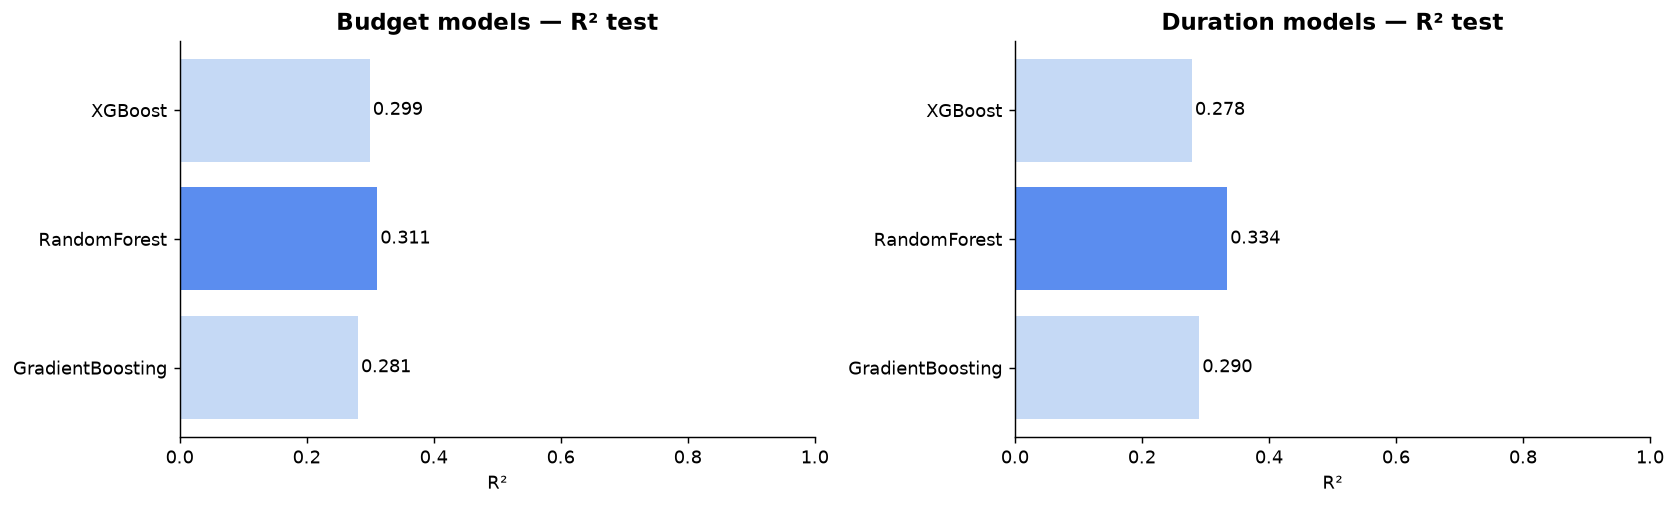

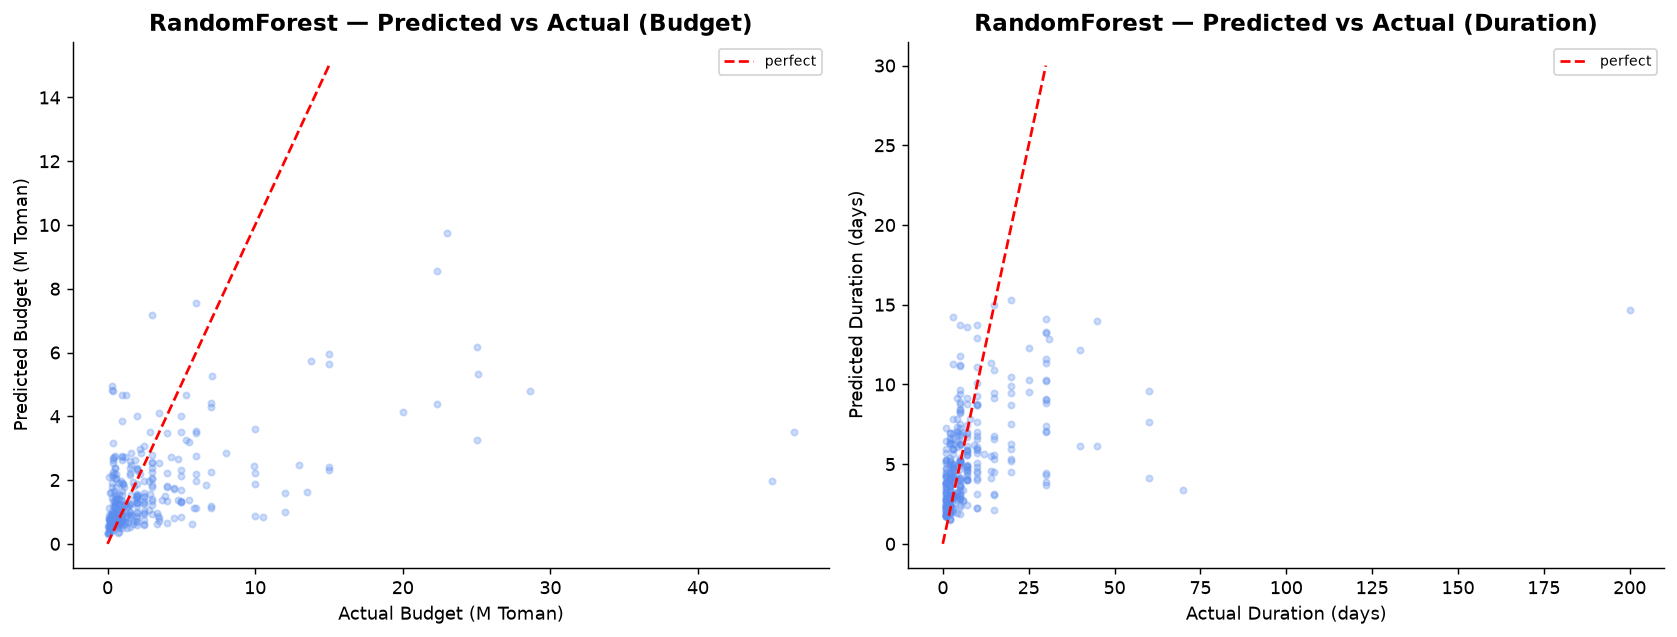

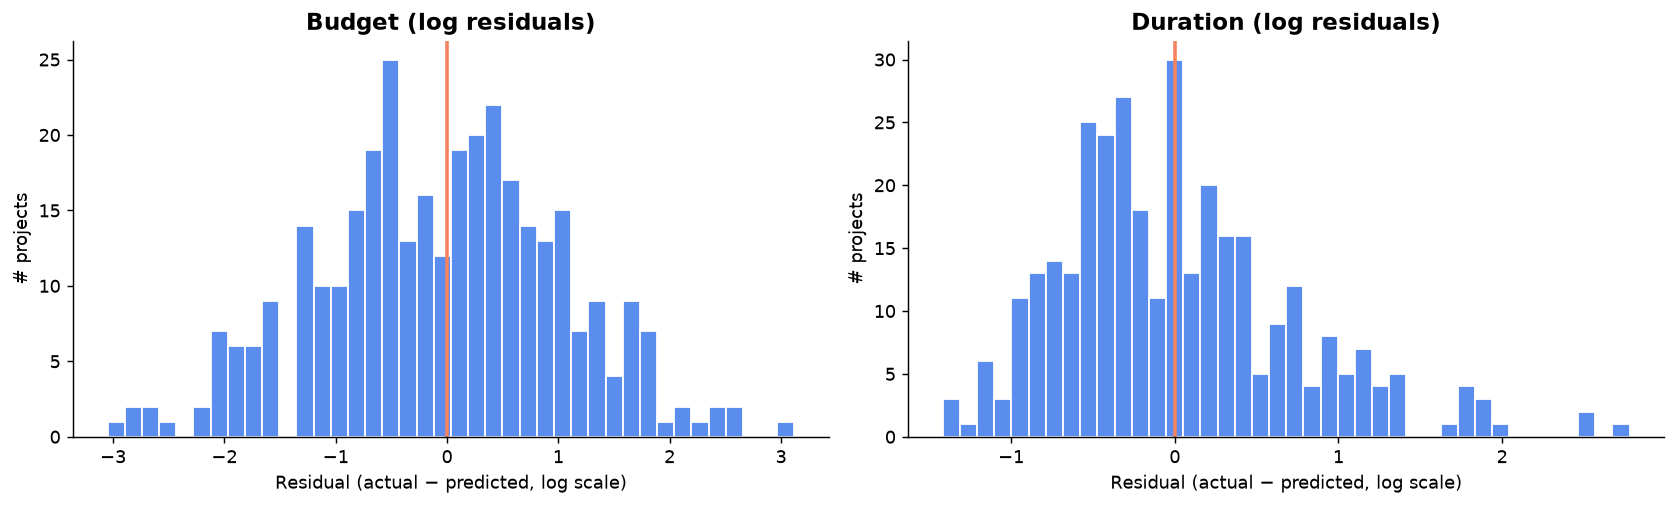

In [8]:
# Side-by-side R² comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, results, title in [
    (axes[0], budget_results,   'Budget models — R² test'),
    (axes[1], duration_results, 'Duration models — R² test'),
]:
    names  = list(results.keys())
    r2s    = [results[n]['r2_test'] for n in names]
    colors = [ACCENT if r == max(r2s) else '#c5d9f5' for r in r2s]
    ax.barh(names, r2s, color=colors)
    for i, v in enumerate(r2s):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_xlabel('R²')
plt.tight_layout(); plt.show()

# Predicted vs actual for best budget model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, res, label, unit in [
    (axes[0], best_budget,   'Budget', 'USD'),
    (axes[1], best_duration, 'Duration', 'days'),
]:
    y_true = np.expm1(yB_te if label=='Budget' else yD_te)
    y_pred = np.expm1(res['pred_test'])
    scale  = 1 if label == 'Budget' else 1  # already in USD, no scaling needed
    ax.scatter(y_true/scale, y_pred/scale, alpha=0.3, s=12, color=ACCENT)
    lim = max(y_true.quantile(0.97), y_pred.max()) / scale
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='perfect')
    ax.set_xlabel(f'Actual {label} ({unit})')
    ax.set_ylabel(f'Predicted {label} ({unit})')
    ax.set_title(f'{res["name"]} — Predicted vs Actual ({label})')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Residuals distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, res, y_te, label in [
    (axes[0], best_budget,   yB_te, 'Budget (log residuals)'),
    (axes[1], best_duration, yD_te, 'Duration (log residuals)'),
]:
    residuals = np.array(y_te) - res['pred_test']
    ax.hist(residuals, bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(0, color=ACCENT2, linewidth=2)
    ax.set_title(label)
    ax.set_xlabel('Residual (actual − predicted, log scale)')
    ax.set_ylabel('# projects')
plt.tight_layout(); plt.show()

## 6b · Classical vs Deep Learning comparison
How does the best tree-based model stack up against the neural net?

In [ ]:
comparison_rows = [
    ('Budget',   best_budget_name,       best_budget['r2_test'],   best_budget['mae_test']),
    ('Budget',   'DeepLearning (MLP)',   dl_budget['r2_test'],     dl_budget['mae_test']),
    ('Duration', best_duration_name,     best_duration['r2_test'], best_duration['mae_test']),
    ('Duration', 'DeepLearning (MLP)',   dl_duration['r2_test'],   dl_duration['mae_test']),
]
comparison_df = pd.DataFrame(comparison_rows, columns=['Target', 'Model', 'R2_test', 'MAE_test'])
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, target in zip(axes, ['Budget', 'Duration']):
    sub = comparison_df[comparison_df['Target'] == target]
    colors = [ACCENT if 'Deep' not in m else ACCENT2 for m in sub['Model']]
    ax.barh(sub['Model'], sub['R2_test'], color=colors)
    for i, (v, m) in enumerate(zip(sub['R2_test'], sub['Model'])):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
    ax.set_title(f'{target} — best classical vs deep learning (R² test)')
    ax.set_xlim(0, 1)
    ax.set_xlabel('R²')
plt.tight_layout(); plt.show()

print()
for target, classical_r2, dl_r2 in [
    ('Budget',   best_budget['r2_test'],   dl_budget['r2_test']),
    ('Duration', best_duration['r2_test'], dl_duration['r2_test']),
]:
    winner = 'classical tree model' if classical_r2 >= dl_r2 else 'deep learning'
    print(f'{target}: {winner} wins on this dataset (classical R²={classical_r2:.3f} vs DL R²={dl_r2:.3f})')
print('\nNote: tree ensembles (GBM/RF/XGBoost) often out-perform small MLPs on tabular')
print('data like this, especially with a few thousand rows and mostly categorical /')
print('count features — deep learning tends to need much more data (or embeddings for')
print('high-cardinality categoricals) to pull ahead here.')


## 7 · Feature importance (global)

=== Budget model feature importance ===


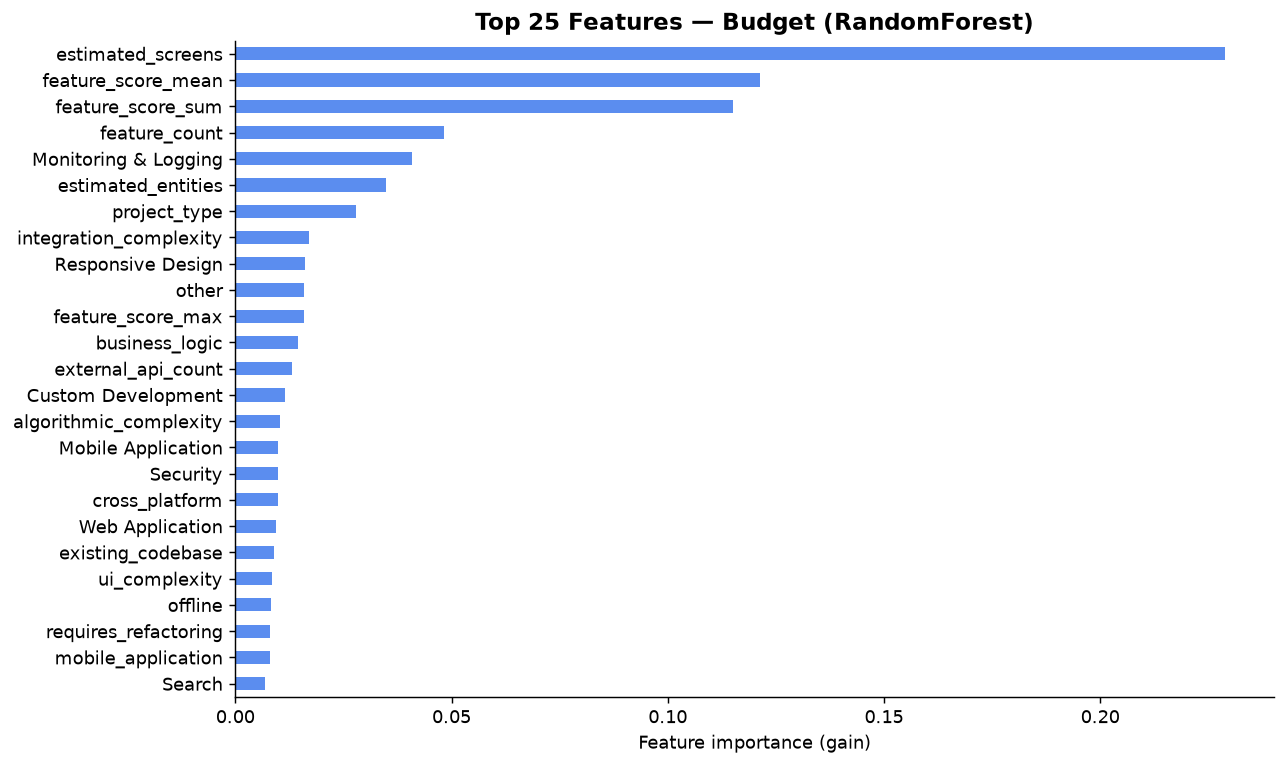

estimated_screens         0.228746
feature_score_mean        0.121343
feature_score_sum         0.115062
feature_count             0.048165
Monitoring & Logging      0.040826
estimated_entities        0.034731
project_type              0.027962
integration_complexity    0.016940
Responsive Design         0.016048
other                     0.015935

=== Duration model feature importance ===


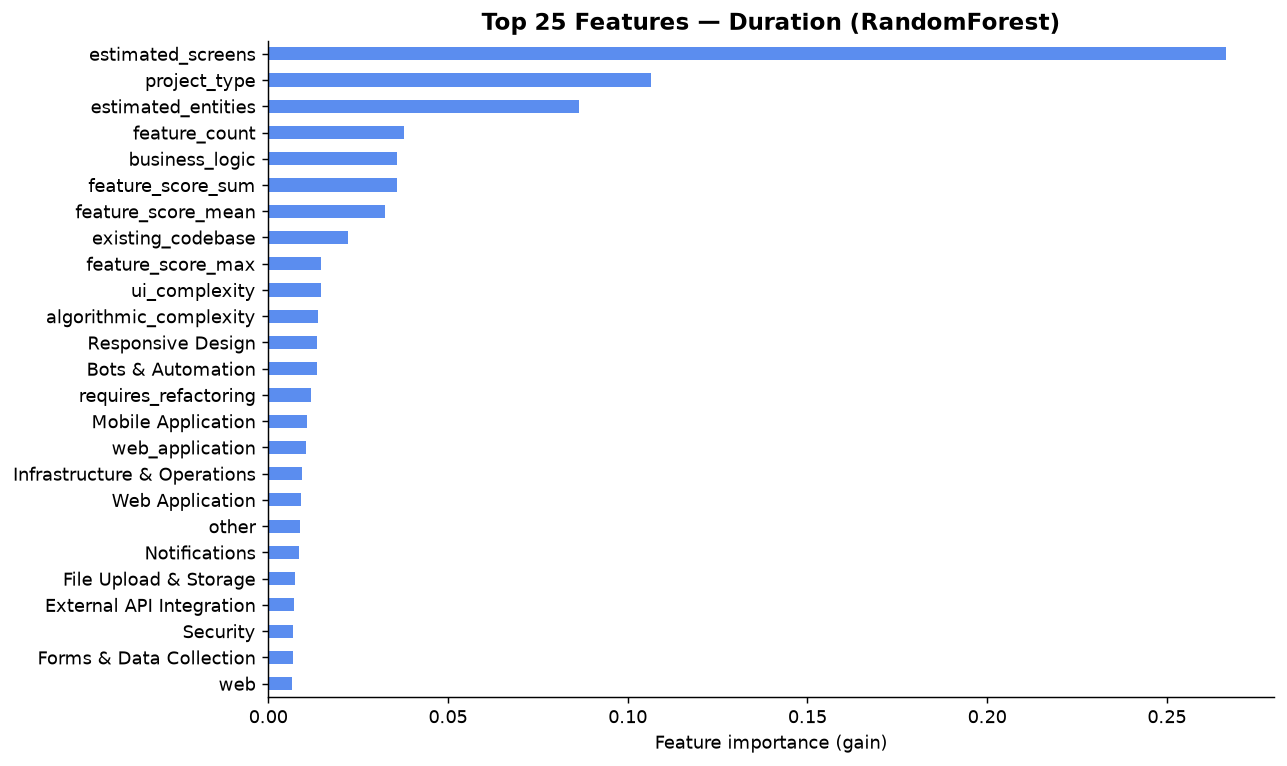

estimated_screens     0.266476
project_type          0.106600
estimated_entities    0.086356
feature_count         0.037635
business_logic        0.035939
feature_score_sum     0.035771
feature_score_mean    0.032397
existing_codebase     0.022245
feature_score_max     0.014797
ui_complexity         0.014577


In [9]:
TOP_N = 25

def plot_importance(model, feature_names, title, top_n=TOP_N):
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
    else:
        return
    imp = imp.nlargest(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    imp[::-1].plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Feature importance (gain)')
    plt.tight_layout(); plt.show()
    return imp

print('=== Budget model feature importance ===')
imp_b = plot_importance(best_budget['model'], ALL_FEATURES, f'Top {TOP_N} Features — Budget ({best_budget_name})')
print(imp_b.head(10).to_string())

print('\n=== Duration model feature importance ===')
imp_d = plot_importance(best_duration['model'], ALL_FEATURES, f'Top {TOP_N} Features — Duration ({best_duration_name})')
print(imp_d.head(10).to_string())

## 8 · SHAP — per-prediction explanations
SHAP shows **why** the model made each prediction, not just which features matter on average.

Computing SHAP values for budget model...


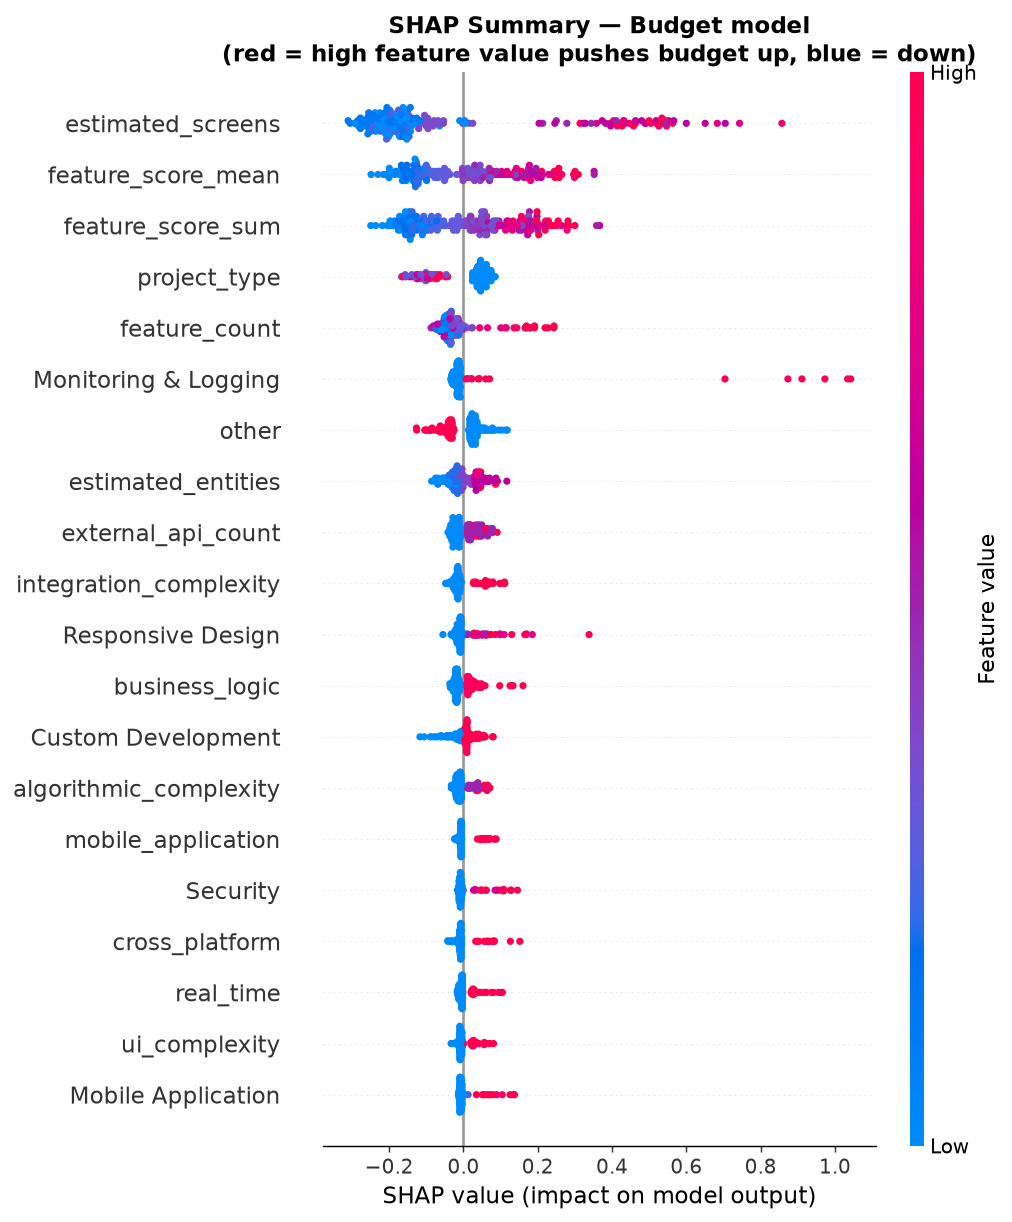

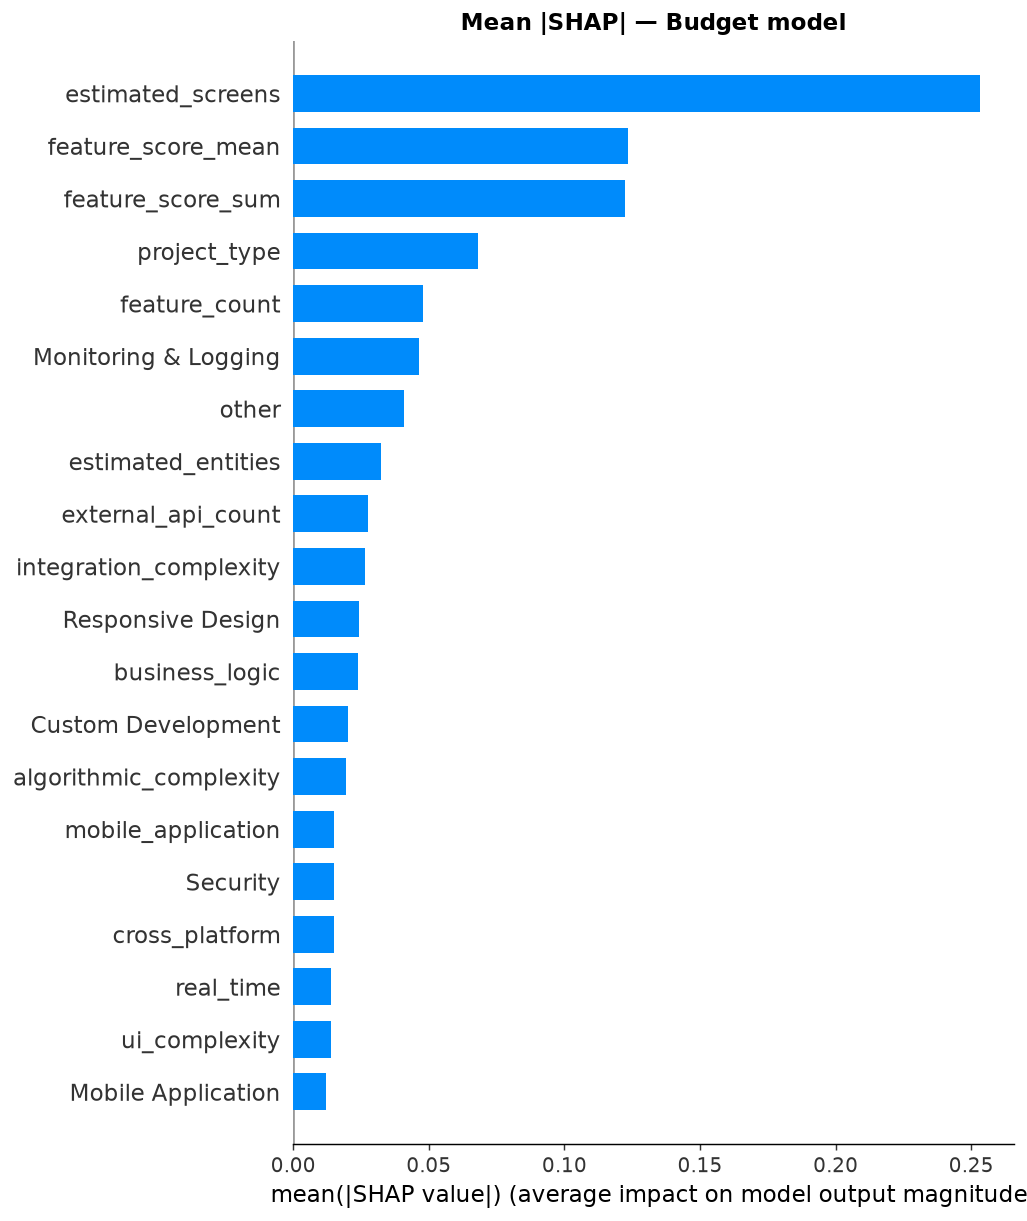


Explaining prediction for sample index 121 (predicted budget: 9,762,288)


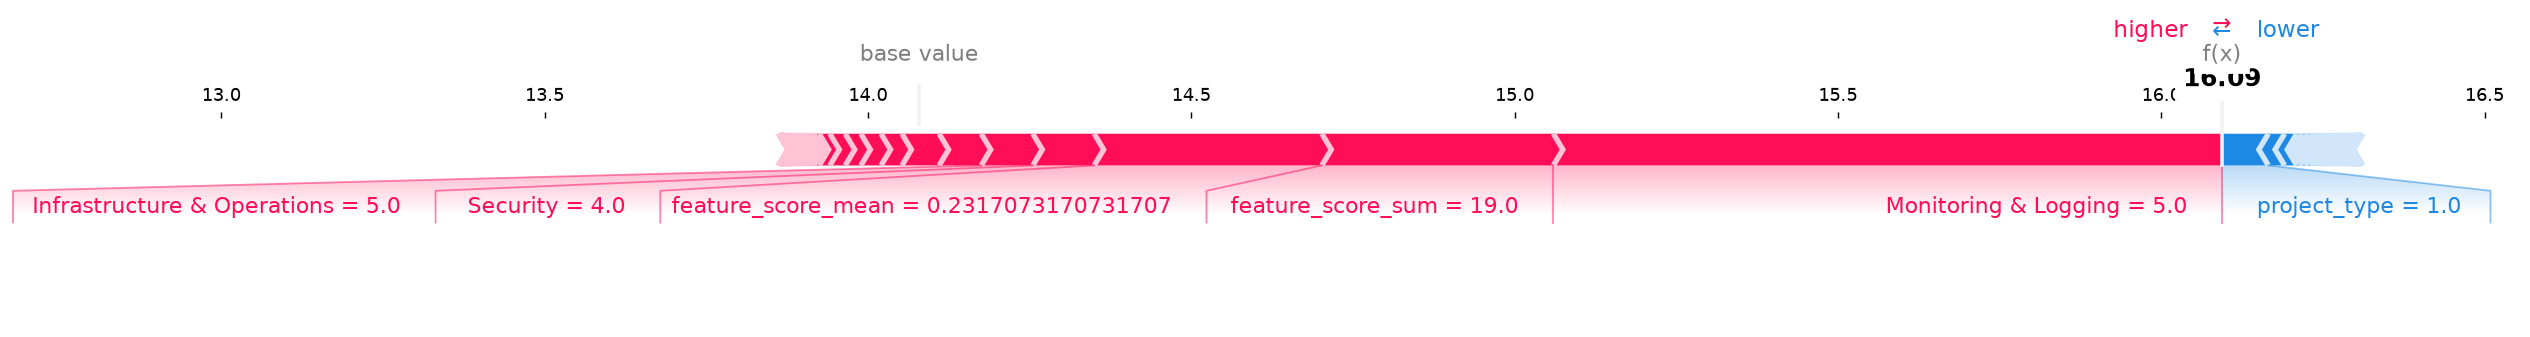

In [10]:
# Use a subsample for speed (SHAP is O(n * features) per call)
SHAP_SAMPLE = min(200, len(X_te))
X_shap = X_te.sample(SHAP_SAMPLE, random_state=42)

print('Computing SHAP values for budget model...')
explainer_b = shap.TreeExplainer(best_budget['model'])
shap_vals_b = explainer_b.shap_values(X_shap)

# Summary plot — global view: which features drive predictions most?
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  max_display=20, show=False)
plt.title('SHAP Summary — Budget model\n(red = high feature value pushes budget up, blue = down)')
plt.tight_layout(); plt.show()

# Bar plot — mean |SHAP| per feature
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP| — Budget model')
plt.tight_layout(); plt.show()

# Single prediction explanation (most expensive predicted project)
idx = np.argmax(np.expm1(best_budget['model'].predict(X_shap)))
print(f'\nExplaining prediction for sample index {idx} '
      f'(predicted budget: {np.expm1(best_budget["model"].predict(X_shap.iloc[[idx]])[0]):,.0f})')
shap.force_plot(explainer_b.expected_value, shap_vals_b[idx], X_shap.iloc[idx],
                feature_names=ALL_FEATURES, matplotlib=True, show=False)
plt.tight_layout(); plt.show()

## 9 · Error analysis
Where does the model fail? Look at the worst predictions to spot patterns.

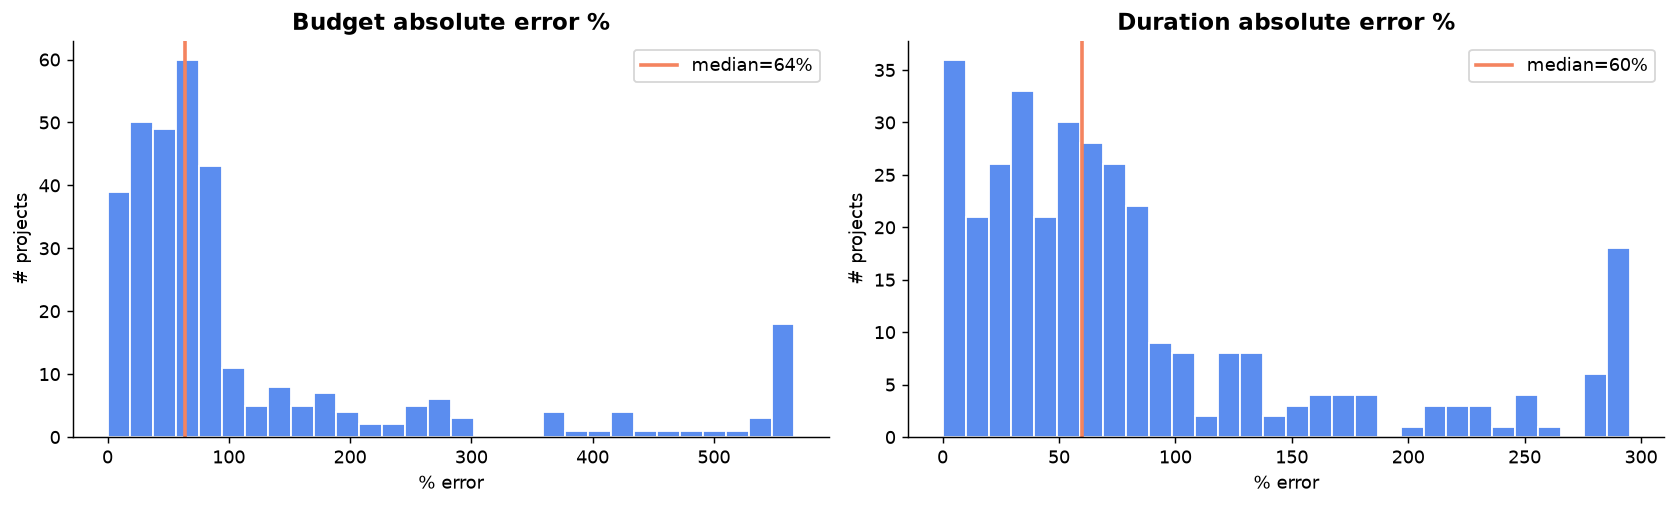

=== 10 worst budget predictions ===
                                               title               category target_budget pred_budget budget_err_pct  feature_count  description_word_count
                   ربات دریافت اطلاعات از هوش مصنوعی پروژه‌های برنامه نویسی          0.1M        2.1M          2010%              6                      56
بخشی از طراحی پنل کاربری با لاراول و اتصال به وردپرس پروژه‌های برنامه نویسی          0.3M        5.0M          1553%             14                     157
                    تنظیم Https (اس اس ال) برای سایت پروژه‌های برنامه نویسی          0.0M        0.6M          1481%              2                      19
           نوشتن معادله با رهیافت SSFM یا FEMیا FDTD پروژه‌های برنامه نویسی          0.1M        1.1M          1359%              3                      13
                     طراحی اپلیکیشن برنامه نویس سریع پروژه‌های برنامه نویسی          0.3M        4.8M          1358%              4                      14
                 طراحی سایت 

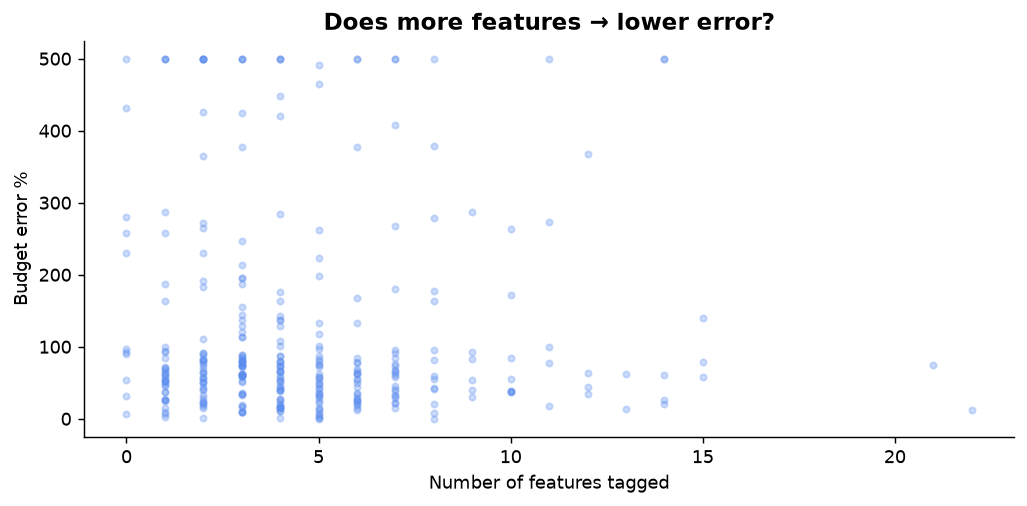

In [11]:
test_idx = X_te.index
error_df = df.loc[test_idx, ['title','category','target_budget','target_duration',
                               'feature_count','description_word_count']].copy()
error_df['pred_budget']   = np.expm1(best_budget['pred_test'])
error_df['pred_duration'] = np.expm1(best_duration['pred_test'])
error_df['budget_err_pct'] = (error_df['pred_budget'] - error_df['target_budget']).abs() / error_df['target_budget'] * 100
error_df['duration_err_pct'] = (error_df['pred_duration'] - error_df['target_duration']).abs() / error_df['target_duration'] * 100

# Error % distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, label in [
    (axes[0], 'budget_err_pct',   'Budget absolute error %'),
    (axes[1], 'duration_err_pct', 'Duration absolute error %'),
]:
    data = error_df[col].clip(upper=error_df[col].quantile(0.95))
    ax.hist(data, bins=30, color=ACCENT, edgecolor='white')
    ax.axvline(data.median(), color=ACCENT2, linewidth=2, label=f'median={data.median():.0f}%')
    ax.set_title(label)
    ax.set_xlabel('% error')
    ax.set_ylabel('# projects')
    ax.legend()
plt.tight_layout(); plt.show()

# Worst predictions
print('=== 10 worst budget predictions ===')
worst = error_df.nlargest(10, 'budget_err_pct')[[
    'title','category','target_budget','pred_budget','budget_err_pct','feature_count','description_word_count'
]]
worst['target_budget'] = worst['target_budget'].map(lambda x: f'${x:,.0f}')
worst['pred_budget']   = worst['pred_budget'].map(lambda x: f'${x:,.0f}')
worst['budget_err_pct'] = worst['budget_err_pct'].map(lambda x: f'{x:.0f}%')
print(worst.to_string(index=False))

# Error vs feature count scatter
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(error_df['feature_count'], error_df['budget_err_pct'].clip(upper=500),
           alpha=0.3, s=12, color=ACCENT)
ax.set_xlabel('Number of features tagged')
ax.set_ylabel('Budget error %')
ax.set_title('Does more features → lower error?')
plt.tight_layout(); plt.show()

## 10 · Cross-validation (more reliable than a single split)

In [12]:
print('5-fold CV R² (budget) — this takes ~30s...')
cv_scores = cross_val_score(best_budget['model'], X, yB, cv=5, scoring='r2', n_jobs=-1)
print(f'  {best_budget_name}: {cv_scores.round(3)}  mean={cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

print('\n5-fold CV R² (duration)...')
cv_scores_d = cross_val_score(best_duration['model'], X, yD, cv=5, scoring='r2', n_jobs=-1)
print(f'  {best_duration_name}: {cv_scores_d.round(3)}  mean={cv_scores_d.mean():.3f} ± {cv_scores_d.std():.3f}')

5-fold CV R² (budget) — this takes ~30s...
  RandomForest: [0.101 0.157 0.341 0.279 0.189]  mean=0.213 ± 0.086

5-fold CV R² (duration)...
  RandomForest: [0.291 0.216 0.272 0.236 0.235]  mean=0.250 ± 0.027


## 11 · Inference helper
Predict budget and duration for a new project — fill in the dict with real values.

In [ ]:
def predict_project(feature_dict: dict) -> dict:
    """
    Pass a dict with the same keys as ALL_FEATURES.
    Missing keys default to 0. Enum values should be strings (e.g. 'medium').
    Returns {'budget': float, 'duration_days': float}.
    """
    row = pd.DataFrame([{f: feature_dict.get(f, 0) for f in ALL_FEATURES}])
    row[ENUM_COLS] = enc.transform(row[ENUM_COLS].astype(str))
    budget_log   = best_budget['model'].predict(row)[0]
    duration_log = best_duration['model'].predict(row)[0]
    return {
        'budget_usd':    int(np.expm1(budget_log)),
        'duration_days': round(np.expm1(duration_log), 1),
    }

# Example: a mid-complexity web app with payment processing
example = {
    'Payment Processing': 4,
    'Authentication': 4,
    'Dashboard': 3,
    'web_application': 1,
    'ecommerce': 1,
    'business_logic': 'medium',
    'ui_complexity': 'medium',
    'integration_complexity': 'medium',
    'algorithmic_complexity': 'low',
    'project_type': 'new',
    'ai_level': 'none',
    'data_volume': 'small',
    'estimated_screens': 12,
    'estimated_entities': 6,
    'external_api_count': 2,
    'description_word_count': 80,
    'feature_count': 8,
    'web': 1,
}

result = predict_project(example)
print(f"Predicted budget:   \${result['budget_usd']:>12,.0f} USD")
print(f"Predicted duration: {result['duration_days']:>12.1f} days")